# Tomography Lite Tutorial
*Cedric Lim, March 23, 2026*

This tutorial shows the usage of `TomographyLite` for conventional and machine-learning enabled reconstruction methods. These methods abstract arguments in the instantiation of the top-level `Tomography` class, i.e instantiation of object and dataset models. 

See `tomography_02_full.ipynb` to see the full reconstruction workflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from quantem.tomography.tomography_lite import TomographyLiteConv, TomographyLiteINR
from quantem.tomography.object_models import ObjConstraintParams
from quantem.tomography.dataset_models import DatasetConstraintParams
import numpy as np
from quantem.core.visualization import show_2d

from quantem.core.utils.tomography_utils import fourier_binning

device = "cuda:0" # Set device

# Launch Tensorboard

The `quantem` Tomography module fully supports Tensorboard logging. You can potentially run Tensorboard by running the below cells, but it is much safer to launch it with your respective `quantem` environment using this command in terminal:

```
tensorboard --logdir ../../../outputs/tomography/tutorial_01_notebooks/
```
*Note: Make sure the log directory is correct, I'm assuming terminal is within the notebook directory. In VSCode/VSCode forks, a port should automatically be port-forwarded. If not, you will have to figure out a way to manually port-forward the tensorboard (e.g. using `ssh -L <local_port>:localhost:<remote_port> <user>@<host>`)*


You may attempt to run the two cells to see if Tensorboard will display inline in the notebook.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ../../../outputs/tomography/tutorial_01_notebooks/

In [ ]:
from tensorboard import notebook
notebook.list() # View open TensorBoard instances
notebook.display(port=6006, height=1000)

# Loading Dataset

The simulated phantom dataset loaded here is a sparse tilt seriesw ith a tilt step of 5 degrees from $\pm70^\circ$ containing a $1^\circ$ tilt-axis error in the tilt series 

In [3]:
# Load Ground Truth Phantom
gt_phantom = np.load('../../../data/phantom.npy').transpose(2, 0, 1)
# Load Phantom Dataset
tilt_series = np.load('../../../data/tilt_series_1_deg_tilt_axis.npy')
tilt_angles = np.load('../../../data/tilt_angles_1_deg_tilt_axis.npy')

# Fourier crop
tilt_series = np.array([fourier_binning(img, (100, 100)) for img in tilt_series]) # Cropped down to 100x100 for speed


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Tilt -70.0'}>,
        <Axes: title={'center': 'Tilt -35.0'}>,
        <Axes: title={'center': 'Tilt 55.0'}>], dtype=object))

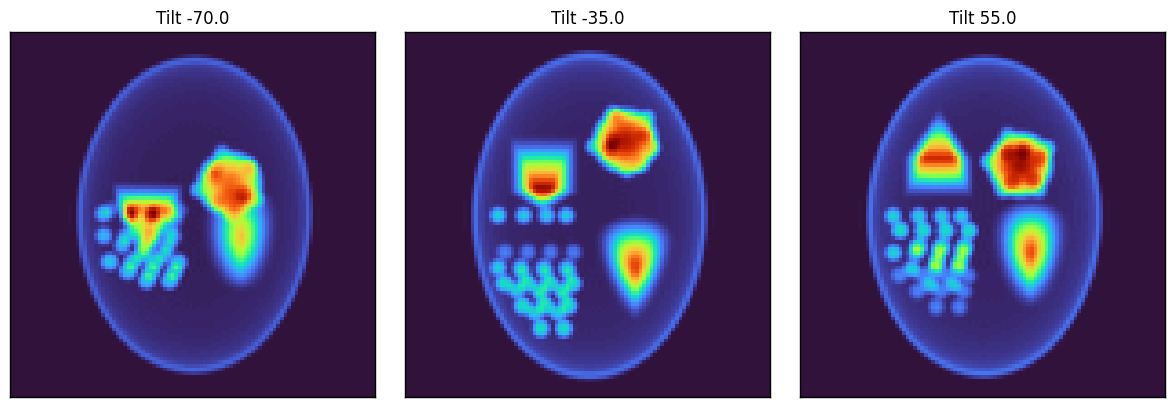

In [4]:
show_2d(
    [tilt_series[0], tilt_series[7], tilt_series[25]],
    title = [f'Tilt {tilt_angles[0]}', f'Tilt {tilt_angles[7]}', f'Tilt {tilt_angles[25]}'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# Conventional Tomography Reconstructions

The default conventional algorithm is simultaneous iterative reconstruction technique (**SIRT**).

In [5]:
tomography = TomographyLiteConv.from_dataset(
    tilt_series = tilt_series,
    tilt_angles = tilt_angles,
    device = device,
)

In [ ]:
tomography.reconstruct(
    num_iter = 10,
    mode = "sirt",
    inline_alignment = True,
    smoothing_sigma = 0.1,
    show_metrics = True
)

sirt Reconstruction | Loss: 0.0000:   0%|          | 0/10 [00:00<?, ?it/s]

sirt Reconstruction | Loss: 0.0389: 100%|██████████| 10/10 [00:00<00:00, 18.32it/s]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Conventional Reconstruction Summed X'}>,
        <Axes: title={'center': 'Conventional Reconstruction Summed Y'}>,
        <Axes: title={'center': 'Conventional Reconstruction Summed Z'}>],
       dtype=object))

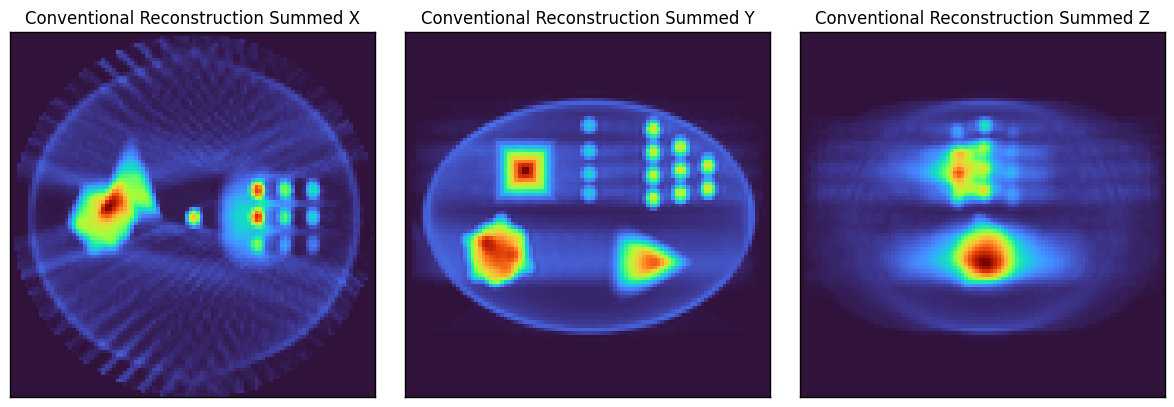

In [7]:
obj_conv = tomography.obj_model.obj.detach().cpu().numpy()
show_2d(
    [obj_conv.sum(axis = 0), obj_conv.sum(axis = 1), obj_conv.sum(axis = 2)],
    title = ['Conventional Reconstruction Summed X', 'Conventional Reconstruction Summed Y', 'Conventional Reconstruction Summed Z'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

The reconstruction here shows artifacts from the small missing wedges due to the large tilt step. Moreover, in the summed Z direction there are some misalignment artifacts due to the tilt-axis error.

# INR-Based Tomography Reconstruction

In [17]:
tomography_inr = TomographyLiteINR.from_dataset(
    tilt_series = tilt_series,
    tilt_angles = tilt_angles,
    device = device,
    log_dir = '../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite',
    log_images_every = 2,
)


Model built, compiled successfully
Setting up DDP for obj_model


In [ ]:
obj_constraints = ObjConstraintParams.ObjINRConstraints(
    positivity=True,
    tv_vol=1e-4,
    sparsity=1e-6,
)

dset_constraints = DatasetConstraintParams.BaseTomographyDatasetConstraints(
    tv_zs = 1e-6,
    tv_shifts = 1e-6,
)

# First iteration of the reconstruct call will be slow due to @torch.compile.
# Subsequent calls will be faster.
tomography_inr.reconstruct(
    num_iter = 30,
    # reset = True,
    obj_lr = 1e-4,
    pose_lr = 1e-2,
    batch_size = 1024,
    num_workers = 32,
    learn_pose = True,
    scheduler_type = "cosine_annealing",
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
    show_metrics = True,
)

Dataloader setup complete:
  Total train samples: 290000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 283


Reconstruction | Loss: 5.13492e-04, Consistency Loss: 4.83327e-05, Soft Constraint Loss: 4.65160e-04 | Images Logged: 100%|██████████| 30/30 [02:26<00:00,  4.88s/it]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
       dtype=object))

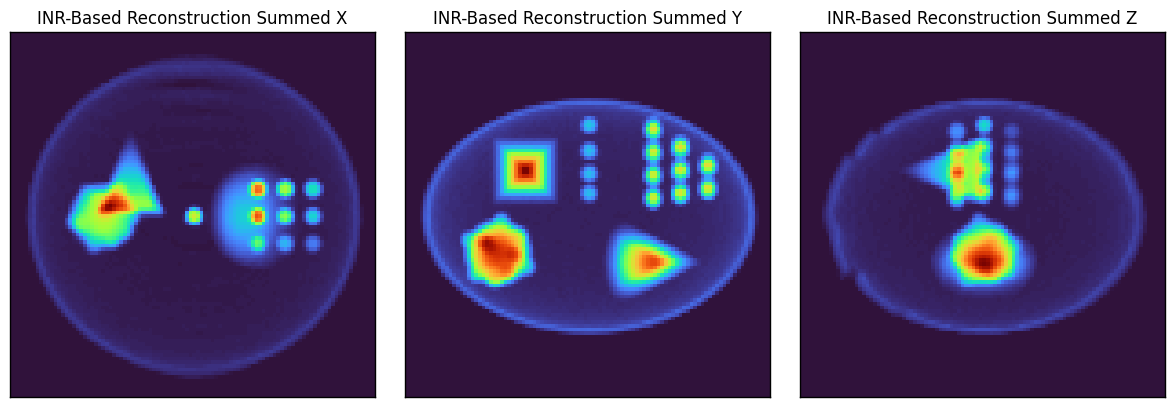

In [24]:
obj_inr = tomography_inr.obj_model.obj_view
show_2d(
    [obj_inr[0].sum(axis = 0), obj_inr[0].sum(axis = 1), obj_inr[0].sum(axis = 2)],
    cmap = 'turbo',
    title = ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
    vmin = 0,
    vmax = None,
)

# Compare Both Reconstruction Methods

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: title={'center': 'Conventional Reconstruction Summed X'}>,
         <Axes: title={'center': 'Conventional Reconstruction Summed Y'}>,
         <Axes: title={'center': 'Conventional Reconstruction Summed Z'}>],
        [<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
         <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
         <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
        [<Axes: title={'center': 'Ground Truth Phantom Summed X'}>,
         <Axes: title={'center': 'Ground Truth Phantom Summed Y'}>,
         <Axes: title={'center': 'Ground Truth Phantom Summed Z'}>]],
       dtype=object))

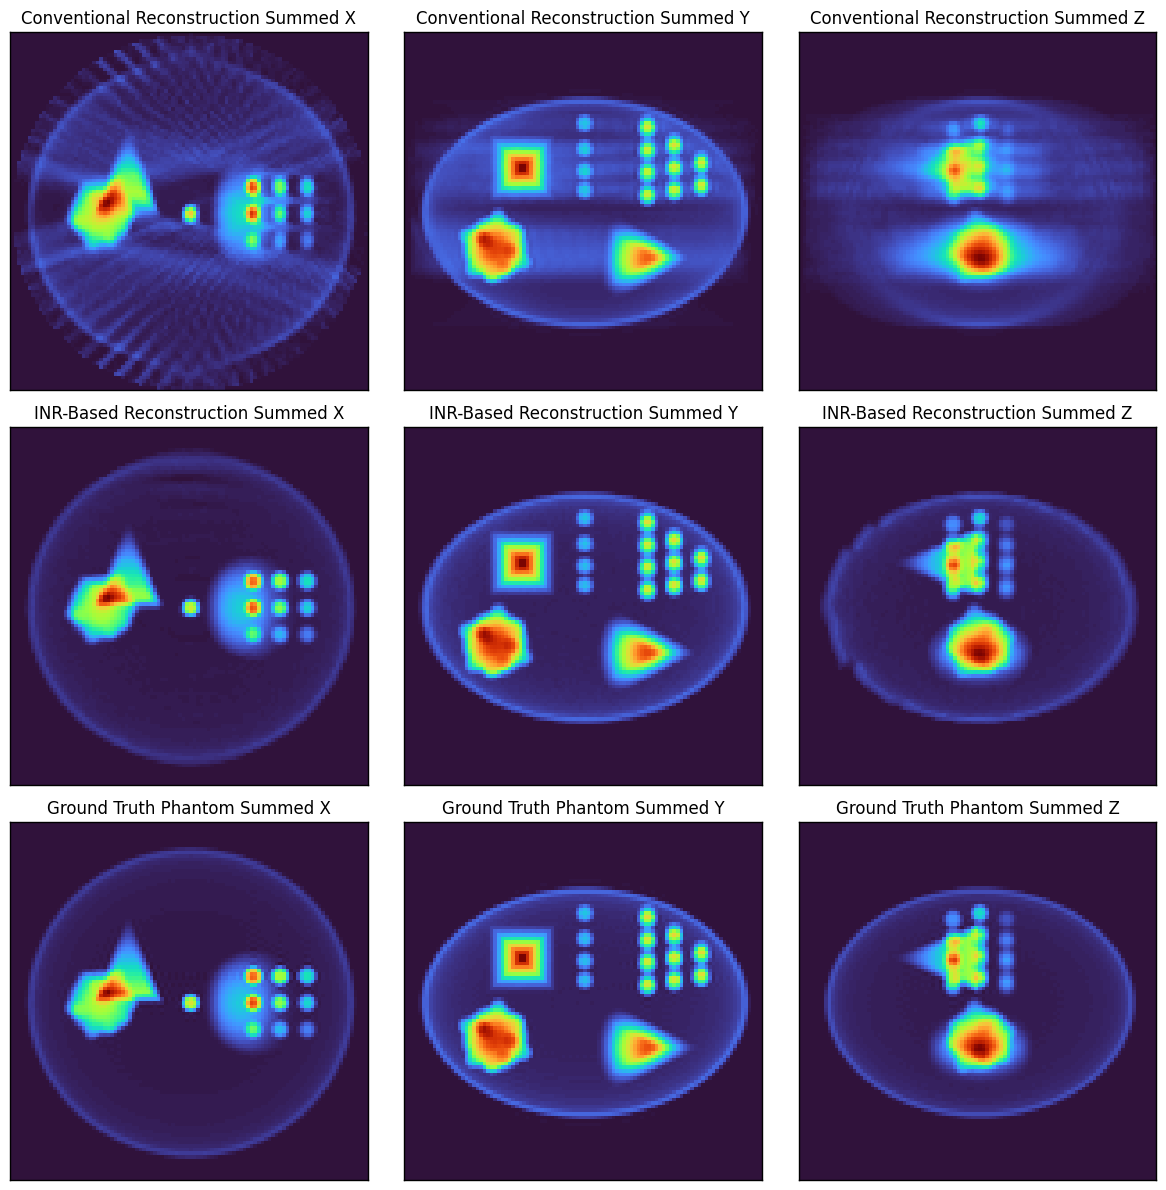

In [25]:
show_2d(
    [
        [obj_conv.sum(axis = 0), obj_conv.sum(axis = 1), obj_conv.sum(axis = 2)],
        [obj_inr[0].sum(axis = 0), obj_inr[0].sum(axis = 1), obj_inr[0].sum(axis = 2)],
        [fourier_binning(gt_phantom.sum(axis = 0), (100, 100)), fourier_binning(gt_phantom.sum(axis = 1), (100, 100)), fourier_binning(gt_phantom.sum(axis = 2), (100, 100))],
    ],
    title = [
        ['Conventional Reconstruction Summed X', 'Conventional Reconstruction Summed Y', 'Conventional Reconstruction Summed Z'],
        ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
        ['Ground Truth Phantom Summed X', 'Ground Truth Phantom Summed Y', 'Ground Truth Phantom Summed Z']
    ],
    cmap = 'turbo',
    vmin = 0,
)

# Saving the Object

In [12]:
tomography_inr.save("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite.zip", mode = "o")

falling back in serialize for _device of type <class 'torch.device'>
falling back in serialize for object of type <class 'quantem.core.ml.optimizer_mixin.SchedulerParams.CosineAnnealing'>
falling back in serialize for pose of type <class 'quantem.core.ml.optimizer_mixin.SchedulerParams.CosineAnnealing'>


In [13]:
# The device is important as it will automatically default to the CPU if not specified causing CUDA errors.
tomo = TomographyLiteINR.from_file("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite.zip", device = device)

Dataloader setup complete:
  Total train samples: 290000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 283


You can continue training from the loaded object as well.

In [14]:
tomo.reconstruct(num_iter = 5)

Reconstruction | Loss: 5.68496e-04, Consistency Loss: 1.02169e-04, Soft Constraint Loss: 4.66327e-04: 100%|██████████| 5/5 [00:37<00:00,  7.45s/it]                


# Saving Final Reconstructed Volume

In [ ]:
tomography_inr.save_volume("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite_volume.npz")

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Summed X'}>,
        <Axes: title={'center': 'Summed Y'}>,
        <Axes: title={'center': 'Summed Z'}>], dtype=object))

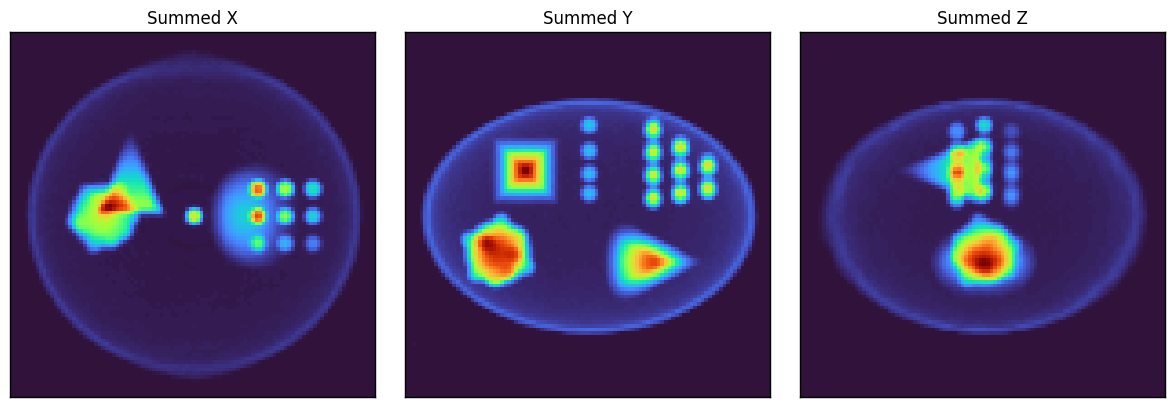

In [17]:
saved_vol = np.load("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite_volume.npz")
show_2d(
    [
        saved_vol["volume"][0].sum(axis = 0),
        saved_vol["volume"][0].sum(axis = 1),
        saved_vol["volume"][0].sum(axis = 2),
    ],
    title = [
        "Summed X",
        "Summed Y",
        "Summed Z",
    ],
    cmap = "turbo",
    vmin = 0,
    vmax = None,
)